# SHAP interpretability

In this notebook, we're going to experiment with SHAP interpretability using `shap` package.

## Environment setup

In [1]:
from pathlib import Path
import sys

# Add the project's "src" directory to Python path
project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

In [2]:
import diabetes_prediction

print(diabetes_prediction.__file__)

D:\Projects\Python\pyml-portfolio\diabetes-prediction\src\diabetes_prediction\__init__.py


In [3]:
import pandas as pd
import shap.plots as plots
from shap import TreeExplainer

from diabetes_prediction.utils.common import load_data
from diabetes_prediction.utils.model import load_local_model

D:\Projects\Python\pyml-portfolio\diabetes-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experimenting with essential plots

In [4]:
pipeline = load_local_model()
pipeline.named_steps

{'transformer': ColumnTransformer(transformers=[('categorical',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('onehotencoder',
                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                  ['gender', 'smoking_history']),
                                 ('numerical',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer()),
                                                  ('standardscaler',
                                                   StandardScaler())]),
                                  ['age', 'bmi', 'HbA1c_level',
                                   'blood_glucose_level']),
                                 ('binary',
                                  SimpleImputer(fill_v

In [5]:
model = pipeline.named_steps["estimator"]
model.get_params()

{'categorical_features': 'from_dtype',
 'class_weight': 'balanced',
 'early_stopping': 'auto',
 'interaction_cst': None,
 'l2_regularization': 0.0,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_bins': 255,
 'max_depth': 5,
 'max_features': 0.8,
 'max_iter': 100,
 'max_leaf_nodes': 31,
 'min_samples_leaf': 20,
 'monotonic_cst': None,
 'n_iter_no_change': 10,
 'random_state': 147,
 'scoring': 'loss',
 'tol': 1e-07,
 'validation_fraction': 0.15,
 'verbose': 0,
 'warm_start': False}

In [6]:
explainer = TreeExplainer(model)

In [8]:
X_test, _ = load_data("test")

transformer = pipeline.named_steps["transformer"]
X_trans = transformer.transform(X_test)

In [9]:
feature_names = transformer.get_feature_names_out()
feature_names

array(['categorical__gender_Female', 'categorical__gender_Male',
       'categorical__gender_Other',
       'categorical__smoking_history_No Info',
       'categorical__smoking_history_current',
       'categorical__smoking_history_ever',
       'categorical__smoking_history_former',
       'categorical__smoking_history_never',
       'categorical__smoking_history_not current', 'numerical__age',
       'numerical__bmi', 'numerical__HbA1c_level',
       'numerical__blood_glucose_level', 'binary__hypertension',
       'binary__heart_disease'], dtype=object)

In [10]:
rename = {
    "categorical__gender_Female": "Gender: Female",
    "categorical__gender_Male": "Gender: Male",
    "categorical__gender_Other": "Gender: Other",
    "categorical__smoking_history_No Info": "Smoking: No Info",
    "categorical__smoking_history_current": "Smoking: Current",
    "categorical__smoking_history_ever": "Smoking: Ever",
    "categorical__smoking_history_former": "Smoking: Former",
    "categorical__smoking_history_never": "Smoking: Never",
    "categorical__smoking_history_not current": "Smoking: Not Current",
    "numerical__age": "Age",
    "numerical__bmi": "BMI",
    "numerical__HbA1c_level": "HbA1c",
    "numerical__blood_glucose_level": "Blood Glucose",
    "binary__hypertension": "Hypertension",
    "binary__heart_disease": "Heart Disease",
}

In [11]:
X_trans = pd.DataFrame(
    X_trans,
    columns=feature_names,
    index=X_test.index,
)
X_trans.head()

,categorical__gender_Female,categorical__gender_Male,categorical__gender_Other,categorical__smoking_history_No Info,categorical__smoking_history_current,categorical__smoking_history_ever,categorical__smoking_history_former,categorical__smoking_history_never,categorical__smoking_history_not current,numerical__age,numerical__bmi,numerical__HbA1c_level,numerical__blood_glucose_level,binary__hypertension,binary__heart_disease
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.566771,-0.358273,0.248818,-0.200286,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.323530,1.170825,-0.682373,0.043879,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.724166,0.056873,-0.496135,0.410127,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.279012,-1.361421,-0.961731,-1.176948,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.501587,0.000732,0.621295,-1.299030,0.0,0.0


In [12]:
X_trans.rename(columns=rename, inplace=True)
X_trans.head()

,Gender: Female,Gender: Male,Gender: Other,Smoking: No Info,Smoking: Current,Smoking: Ever,Smoking: Former,Smoking: Never,Smoking: Not Current,Age,BMI,HbA1c,Blood Glucose,Hypertension,Heart Disease
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.566771,-0.358273,0.248818,-0.200286,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.323530,1.170825,-0.682373,0.043879,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.724166,0.056873,-0.496135,0.410127,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.279012,-1.361421,-0.961731,-1.176948,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.501587,0.000732,0.621295,-1.299030,0.0,0.0


In [13]:
shap_values = explainer(X_trans)

## Summary / Feature importance plot

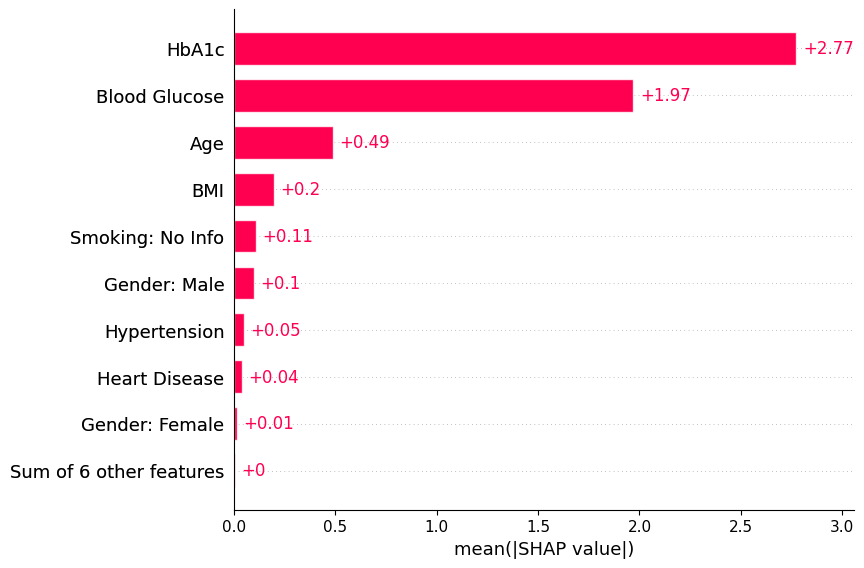

In [14]:
plots.bar(shap_values)

### Explanation

If the model could only look at one or two pieces of information, it would choose HbA1c and Blood Glucose.

## Beeswarm plot

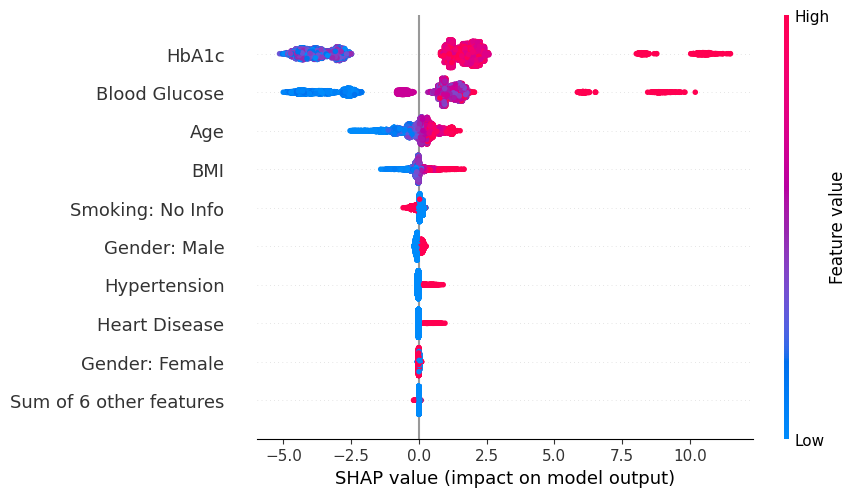

In [15]:
plots.beeswarm(shap_values)

### Explanation

The model behaves consistently with medical intuition. High HbA1c and high blood glucose
strongly increase predicted risk, while age and BMI have a moderate effect. Other variables
fine-tune the prediction but rarely dominate it.

## Waterfall plot

This plot provides local explanability for a single data point. Common practice is to use
a particularly interesting data point, where this plot will provide useful interpretation.

Based on the batch inference we demonstrate in `predict.py` module, a single data point is
particularly interesting, because our model correctly predicts the label (Positive) for it
in *triage* mode, but the very same data points causes a *False Negative* in *balanced* mode.

We're going to check waterfall plot on this test set instance, whose index number is **349**.

In [16]:
idx = 349
X_test.iloc[idx]

gender                 Female
age                      55.0
hypertension                0
heart_disease               0
smoking_history          ever
bmi                     36.23
HbA1c_level               5.8
blood_glucose_level       145
Name: 349, dtype: object

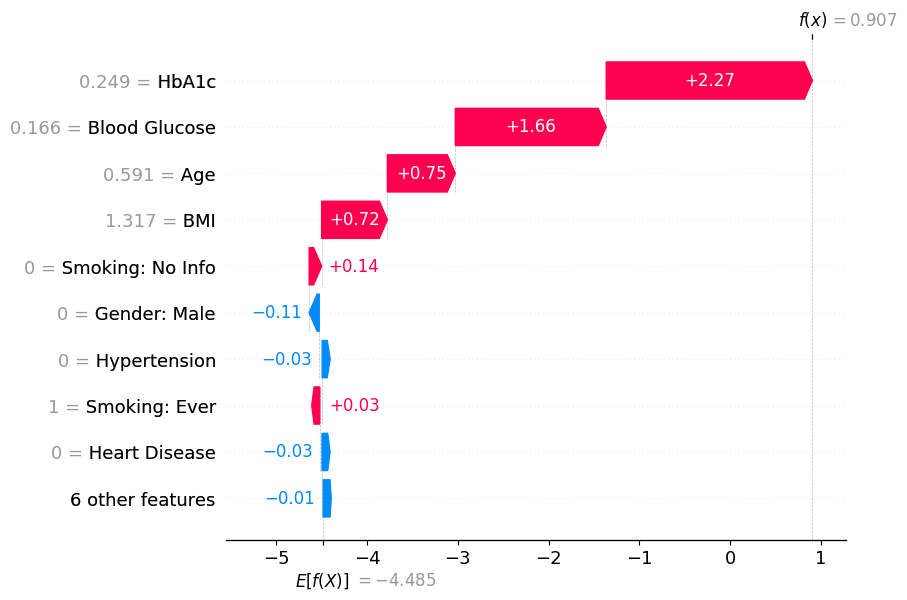

In [17]:
plots.waterfall(shap_values[idx])

### Explanation

Based on the following observations :

- HbA1c is high
- Blood Glucose is high
- Age is relatively high
- BMI is relatively high

The model is strongly convinced there's a high chance of diabetes (90.7%). Other factors
also affect this decision, although with much lower contributions.

This patient

- is predicted Positive in triage mode
- but becomes Negative in balanced mode.

That is **not** because SHAP changes.

SHAP is saying :

> "The model believes this patient has roughly a 91% probability."

The operating policy then decides :

In *triage* mode :

```
triage threshold

↓

Positive
```

In *balanced* mode :

```
balanced threshold

↓

Negative
```

This can be interpreted as :

> "The explanation of the prediction never changes. Only the clinical decision policy changes."

This example is indeed interesting, because it illustrates the distinction between
**model confidence** and **business (or clinical) decision-making**.

## Final conclusion

SHAP analysis shows that the model's predictions are driven primarily by
**HbA1c** and **Blood Glucose**, followed by **Age** and **BMI**.
This aligns well with established medical knowledge about diabetes risk factors.
Local explanations further demonstrate how individual features contribute to a
prediction, allowing clinicians to understand why the model considered a specific
patient to be at high or low risk. The explanations remain the same regardless of
the chosen operating threshold (triage or balanced), since SHAP explains the model's
estimated probability rather than the downstream decision policy.